In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
import warnings
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('source/FReDA4.csv')

In [4]:
# df2 = df.dropna(subset=traits).copy()
# print(df2['Group3'].value_counts())

In [5]:
mask1 = (
    df.groupby('CoupleId')['Frequency_F']
    .nunique()
    .eq(1)
)

mask2 = (
    df.groupby('CoupleId')['Desire_F']
    .nunique()
    .eq(1)
)

df['Match_Frequency'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask1.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask1.get(cid, False) else 0
)
df['Match_Frequency_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask1.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask1.get(cid, False) else 0
)

df['Match_Desire'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask2.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask2.get(cid, False) else 0
)

df['Match_Desire_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask2.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask2.get(cid, False) else 0
)

In [6]:
df = df.rename(columns={
    'Work Status': 'Work_Status',

    'Self-esteem': 'Self_esteem',
    'Life Satisfaction': 'Life_Satisfaction',

    'Relationship Sex': 'Relationship_Sex',
    'Relationship Length': 'Relationship_Length',
    'Age difference': 'Age_Difference',
    'Communication Quality': 'Communication_Quality',
    'Relationship Satisfaction': 'Relationship_Satisfaction',
    'Conflict Management': 'Conflict_Management'
})

In [12]:
traits = [
    'Match_Frequency_n',

    'Sex',
    'Age',
    'Work_Status',
    'Education',
    'Urbanization',

    'Extraversion',
    'Agreeableness',
    'Conscientiousness',
    'Openness',
    'Neuroticism',
    'Conservatism',
    'Religiosity',

    'Depressiveness',
    'Loneliness',
    'Self_esteem',
    'Life_Satisfaction',
    'Health',

    'Relationship_Sex',
    'Relationship_Length',
    'Age_Difference',
    'Married',
    'Cohabitation',
    'Kids',
    'Communication_Quality',
    'Relationship_Satisfaction',
    'Conflict_Management',
]

In [13]:
print(len(traits))

27


In [14]:
# 1. (1 = Satisfied, 0 = All others)
df['Is_Satisfied'] = np.where(df['Group3'] == 'Couple Satisfaction', 1, 0)

In [15]:
potential_predictors = traits
significant_predictors = []

In [16]:
for var in potential_predictors:
    # Check bivariate association
    formula = f"Is_Satisfied ~ {var}"

    model = smf.gee(formula,
                    groups=df['CoupleId'],
                    data=df,
                    family=sm.families.Binomial()
                    ).fit()

    # If p-value of the predictor is significant (< 0.05), keep it
    p_val = model.pvalues.iloc[1]
    if p_val < 0.05:
        significant_predictors.append(var)

In [17]:
print('Significant predictors found:', len(significant_predictors))
print(significant_predictors)

Significant predictors found: 20
['Match_Frequency_n', 'Age', 'Work_Status', 'Extraversion', 'Agreeableness', 'Conscientiousness', 'Openness', 'Neuroticism', 'Depressiveness', 'Loneliness', 'Self_esteem', 'Life_Satisfaction', 'Health', 'Relationship_Length', 'Married', 'Cohabitation', 'Kids', 'Communication_Quality', 'Relationship_Satisfaction', 'Conflict_Management']


In [18]:
final_formula = "Is_Satisfied ~ " + " + ".join(significant_predictors)

# Using GEE with a Binomial family acts as a logistic regression that adjusts StdErrs for couples
final_model = smf.gee(final_formula,
                      groups=df['CoupleId'],
                      data=df,
                      family=sm.families.Binomial()
                      ).fit()

In [19]:
# 4. Adjusted Odds Ratios (AOR) and 95% Confidence Intervals
results_df = pd.DataFrame({
    'AOR': np.exp(final_model.params),
    'Lower CI': np.exp(final_model.conf_int()[0]),
    'Upper CI': np.exp(final_model.conf_int()[1]),
    'p-value': final_model.pvalues
})
print(results_df)

                                AOR  Lower CI  Upper CI       p-value
Intercept                  0.001593  0.000621  0.004088  5.859398e-41
Match_Frequency_n          1.173854  1.040710  1.324031  9.064967e-03
Age                        1.015526  1.006935  1.024190  3.789602e-04
Work_Status                1.143025  1.070599  1.220351  6.267327e-05
Extraversion               0.980815  0.958666  1.003476  9.646905e-02
Agreeableness              0.977031  0.954736  0.999847  4.850226e-02
Conscientiousness          0.989375  0.968420  1.010783  3.280609e-01
Openness                   1.003848  0.981867  1.026320  7.338735e-01
Neuroticism                0.994115  0.969073  1.019803  6.502028e-01
Depressiveness             0.998155  0.957156  1.040911  9.312364e-01
Loneliness                 0.879346  0.830533  0.931028  1.021417e-05
Self_esteem                1.033708  1.007027  1.061097  1.296311e-02
Life_Satisfaction          1.005012  0.966803  1.044732  8.004053e-01
Health              

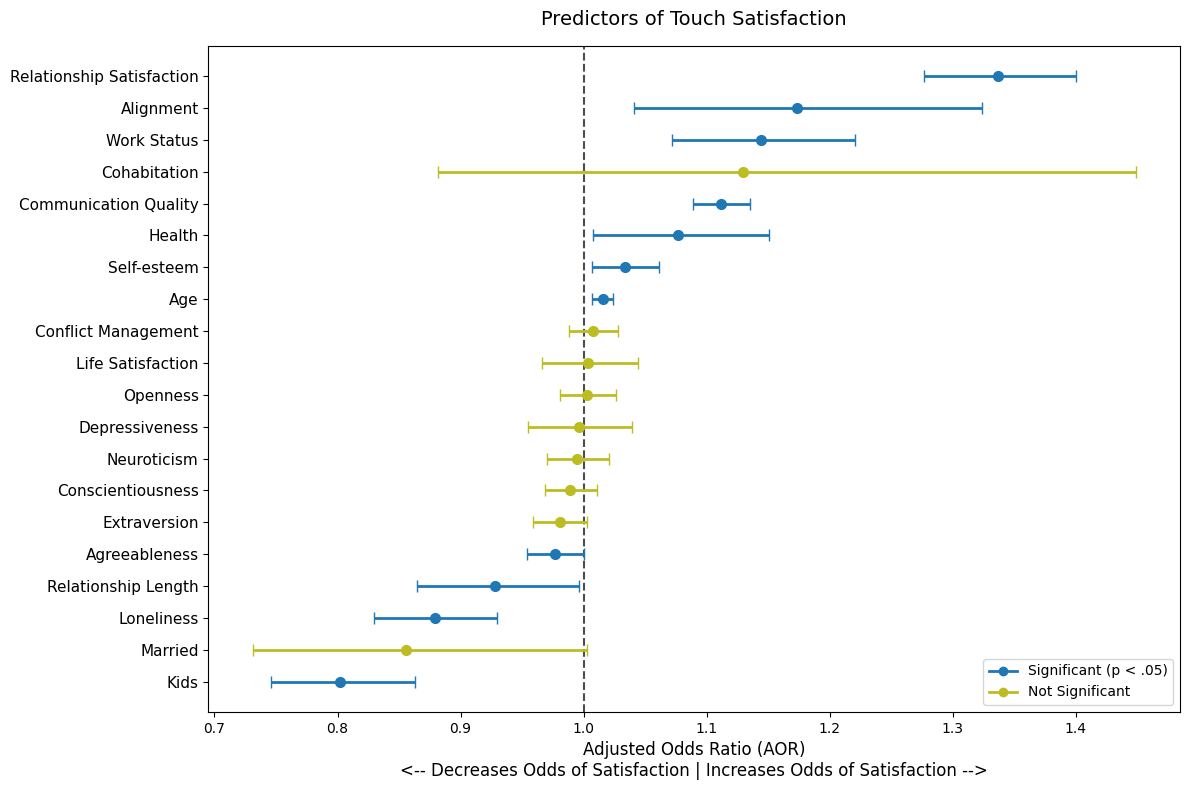

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Your exact model output
data = {
    "Variable": [
        "Relationship Satisfaction", "Alignment", "Work Status", "Cohabitation", "Communication Quality",
        "Health", "Self-esteem", "Age", "Conflict Management", "Life Satisfaction",
        "Openness", "Depressiveness", "Neuroticism", "Conscientiousness",
        "Extraversion", "Agreeableness", "Relationship Length",
        "Loneliness", "Married", "Kids"
    ],
    "AOR": [1.337, 1.173854, 1.144, 1.130, 1.112, 1.077, 1.034, 1.016, 1.008, 1.004, 1.003,
            0.996, 0.995, 0.989, 0.981, 0.977, 0.928, 0.879, 0.856, 0.802],
    "Lower_CI": [1.277,1.040710, 1.072, 0.882, 1.089, 1.008, 1.007, 1.007, 0.988, 0.966, 0.981,
                 0.955, 0.970, 0.969, 0.959, 0.954, 0.865, 0.830, 0.731, 0.746],
    "Upper_CI": [1.400,1.324031, 1.221, 1.449, 1.135, 1.151, 1.061, 1.024, 1.028, 1.044, 1.026,
                 1.039, 1.021, 1.011, 1.003, 1.000, 0.996, 0.930, 1.003, 0.863],
    "p_value": [0.000, 0.000, 0.000,0.334, 0.000, 0.029, 0.012, 0.000, 0.448, 0.838, 0.781,
                0.863, 0.697, 0.334, 0.096, 0.045, 0.039, 0.000, 0.054, 0.000]
}

df = pd.DataFrame(data)

# Calculate error margins for plotting (Distance from AOR to CI boundaries)
df["err_lower"] = df["AOR"] - df["Lower_CI"]
df["err_upper"] = df["Upper_CI"] - df["AOR"]

# Sort the dataframe so the highest AORs are at the top of the plot
df = df.sort_values('AOR', ascending=True).reset_index(drop=True)

# 2. Set up the plot aesthetics
plt.figure(figsize=(12, 8))
plt.style.use('default')

# 3. Create colors based on significance (p < 0.05)
colors = ['#1f77b4' if p < 0.05 else '#bcbd22' for p in df['p_value']]

# 4. Plot the error bars and points
for i, row in df.iterrows():
    plt.errorbar(
        x=row['AOR'],
        y=i,
        xerr=[[row['err_lower']], [row['err_upper']]],
        fmt='o',
        color=colors[i],
        ecolor=colors[i],
        capsize=4,
        markersize=7,
        linewidth=2
    )

# 5. Draw the crucial "Line of No Effect" (AOR = 1)
plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, zorder=0)

# 6. Formatting the axes and labels
plt.yticks(range(len(df)), df['Variable'], fontsize=11)
plt.xlabel("Adjusted Odds Ratio (AOR)\n<-- Decreases Odds of Satisfaction | Increases Odds of Satisfaction -->", fontsize=12)
plt.title("Predictors of Touch Satisfaction", fontsize=14, pad=15)

# 7. Add a custom legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#1f77b4', lw=2, marker='o'),
                Line2D([0], [0], color='#bcbd22', lw=2, marker='o')]
plt.legend(custom_lines, ['Significant (p < .05)', 'Not Significant'], loc='lower right')

plt.tight_layout()

plt.savefig("output/img/Forest_Plot_Satisfaction2.png", dpi=300, bbox_inches='tight')
plt.show()